In [1]:
import os
import logging, timeit
#from btEngine2.DataLoader import DataLoader
from btEngine2.MarketData import MarketData
from btEngine2.TradingRule import TradingRule
import matplotlib.pyplot as plt


import platform
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.0f}' if abs(x) >= 1000 else (f'{x:.2f}' if abs(x) < 10 else f'{x:.1f}')
pd.set_option('future.no_silent_downcasting', True)


# Detect operating system
if platform.system() == "Windows":
    ticker_csv_path = r'G:\Projects\BackTesting1.0\Data\Inputs\TickerList-Futs.csv'
    save_directory = r"G:\Projects\BackTesting1.0\Data\Bloomberg\Futures"
    helper_directory = r'G:\Projects\BackTesting1.0\Data\Bloomberg\HelperFiles'
    bt_folder = r'BackTests\bo_resrch_ml_3'
    av_folder = r'G:\Projects\BackTesting1.0\Data\Inputs\AssetSizing-Futs.csv'
else:  # Assume macOS for other cases
    ticker_csv_path = r'Data/Inputs/TickerList-Futs.csv'
    save_directory = r"Data/Bloomberg/Futures"
    helper_directory = r'Data/Bloomberg/HelperFiles'
    bt_folder = r'BackTests/bo_resrch_ml_3'
    av_folder = r'Data/Inputs/AssetSizing-Futs.csv'



# Define paths to auxiliary data for MarketData
tick_values_path = os.path.join(helper_directory, 'fut_val_pt.parquet')
fx_rates_path = os.path.join(helper_directory, 'fxHist.parquet')

# Initialize the MarketData
market_data = MarketData(
    base_directory=save_directory,
    tick_values_path=tick_values_path,
    fx_rates_path=fx_rates_path,
    instrument_type="Futures",
    n_threads=8,  # Number of threads for parallel data loading
    log_level=logging.ERROR  # Set to DEBUG for more detailed logs
)


In [2]:
tick = 'BR1 Curncy'
# Access data for a specific ticker
try:
    test_df = market_data.get_ticker_data(tick)
    print(test_df)
except ValueError as e:
    print(e)

# Access all preprocessed data
all_data = market_data.get_data()
print(f"Total tickers loaded: {len(all_data)}")

# Access FX rates
fx_rates = market_data.get_fx_rates()
# Access tick values
tick_values = market_data.get_tick_values()
# Access asset classes
asset_classes = market_data.get_asset_classes()

test_df.to_pandas().to_clipboard()
#market_data = market_data.date_filter(start_date='01012010')

shape: (2_374, 14)
┌────────────┬────────┬────────┬────────┬───┬─────────┬─────────┬─────────────────┬────────────────┐
│ Date       ┆ Open   ┆ High   ┆ Low    ┆ … ┆ BadOHLC ┆ FX_Rate ┆ Tick_Value_Base ┆ Tick_Value_USD │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---     ┆ ---     ┆ ---             ┆ ---            │
│ date       ┆ f64    ┆ f64    ┆ f64    ┆   ┆ bool    ┆ f64     ┆ f64             ┆ f64            │
╞════════════╪════════╪════════╪════════╪═══╪═════════╪═════════╪═════════════════╪════════════════╡
│ 2015-07-01 ┆ 19.27  ┆ 19.295 ┆ 18.87  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-02 ┆ 18.98  ┆ 19.365 ┆ 18.95  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-06 ┆ 19.295 ┆ 19.03  ┆ 18.84  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-07 ┆ 18.585 ┆ 18.595 ┆ 18.375 ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-08 ┆ 18.445 ┆ 18.445 ┆ 17.98  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0

In [3]:

from btEngine2.Rules.Momentum.sbo_long import *
from btEngine2.Rules.Momentum.sbo_short import *


pSizeParamsUse = {
    'AssetVol': av_folder,  # Target asset volatility in USD
    'VolLookBack': 30,
    'VolMethod': 'ewm'  # Lookback period for volatility calculation
}

rf_long_tf = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, trend_filter=(100, 'ema'))
rf_short_tf = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, trend_filter=(100, 'ema'))

rf_long = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.75)
rf_short = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.75)

rf_long_tf_2 = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, trend_filter=(100, 'ema'),lb_penalty=-2)
rf_short_tf_2 = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, trend_filter=(100, 'ema'), lb_penalty=-2)

rf_long_2 = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, lb_penalty=-2)
rf_short_2 = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.75, lb_penalty=-2)


In [4]:
def get_variable_name(var, globals_dict):
    return [name for name in globals_dict if globals_dict[name] is var]


trading_rules_dict = {}

# Define the trading rule functions and their corresponding parameters
trading_rule_functions = {
    'rsi_l_ml': (bo_rsi_long_ml, [rf_long_tf, rf_long, rf_long_tf_2, rf_long_2]),
    'rsi_s_ml': (bo_rsi_short_ml, [rf_short_tf, rf_short, rf_short_tf_2, rf_short_2]),
}


# Loop through each trading rule function and its parameters
for rule_name, (rule_function, params_list) in trading_rule_functions.items():
    for params in params_list:
        print(params)
        print(f'name: {get_variable_name(params, globals())[0]}')
        rule_label = get_variable_name(params, globals())[0]
        print(rule_label)
        print('---------------------------------')

        trading_rules_dict[rule_label] = TradingRule(
            market_data=market_data,
            trading_rule_function=rule_function,
            trading_params=params,
            position_sizing_params=pSizeParamsUse,
            cont_rule=False,
            name_label=rule_label,
            bt_folder=bt_folder,
            log_level = logging.ERROR
        )

trading_rules_dict


{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75, 'trend_filter': (100, 'ema')}
name: rf_long_tf
rf_long_tf
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75}
name: rf_long
rf_long
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75, 'trend_filter': (100, 'ema'), 'lb_penalty': -2}
name: rf_long_tf_2
rf_long_tf_2
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75, 'lb_penalty': -2}
name: rf_long_2
rf_long_2
---------------------------------
{'rsi_param': (7, 10), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75, 'trend_filter': (100, 'ema')}
name: rf_short_tf
rf_short_tf
---------------------------------
{'rsi_param': (7, 10), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.75}
name: rf_short
rf_sh

{'rf_long_tf': <btEngine2.TradingRule.TradingRule at 0x3127967b0>,
 'rf_long': <btEngine2.TradingRule.TradingRule at 0x110877ef0>,
 'rf_long_tf_2': <btEngine2.TradingRule.TradingRule at 0x3123667b0>,
 'rf_long_2': <btEngine2.TradingRule.TradingRule at 0x313824560>,
 'rf_short_tf': <btEngine2.TradingRule.TradingRule at 0x313824710>,
 'rf_short': <btEngine2.TradingRule.TradingRule at 0x313824a40>,
 'rf_short_tf_2': <btEngine2.TradingRule.TradingRule at 0x313824d10>,
 'rf_short_2': <btEngine2.TradingRule.TradingRule at 0x3138250d0>}

In [6]:
try:
    readme_path = r'/Users/utkarsh/Documents/Projects/system/systr/BackTests/bo_resrch_ml_2/bo_rsi_short_ml_808d89_e7b522_rsi_s_ml/README.txt'
    exclude = []
    # Initialize TradingRule from README file
    rf_short_tf_lt = TradingRule.from_readme(
        readme_path=readme_path,
        market_data=market_data,
        excl_ac=exclude,
        log_level=logging.ERROR,
        # Include any other necessary arguments
    )

    rf_short_tf_lt.name_lbl = 'rf_short_tf_lt'

    readme_path = r'/Users/utkarsh/Documents/Projects/system/systr/BackTests/bo_resrch_ml_2/bo_rsi_short_ml_f2ae4e_e7b522_rsi_s_ml/README.txt'
    # Initialize TradingRule from README file
    rf_short_lt = TradingRule.from_readme(
        readme_path=readme_path,
        market_data=market_data,
        excl_ac=exclude,
        log_level=logging.ERROR,
        # Include any other necessary arguments
    )

    rf_short_lt.name_lbl = 'rf_short_lt'


    readme_path = r'/Users/utkarsh/Documents/Projects/system/systr/BackTests/bo_resrch_ml_2/bo_rsi_long_ml_2f8791_e7b522_rsi_l_ml/README.txt'
    exclude = []
    # Initialize TradingRule from README file
    rf_long_tf_lt = TradingRule.from_readme(
        readme_path=readme_path,
        market_data=market_data,
        excl_ac=exclude,
        log_level=logging.ERROR,
        # Include any other necessary arguments
    )

    rf_long_tf_lt.name_lbl = 'rf_long_tf_lt'

    readme_path = r'/Users/utkarsh/Documents/Projects/system/systr/BackTests/bo_resrch_ml_2/bo_rsi_long_ml_6cb2bd_e7b522_rsi_l_ml/README.txt'
    # Initialize TradingRule from README file
    rf_long_lt = TradingRule.from_readme(
        readme_path=readme_path,
        market_data=market_data,
        excl_ac=exclude,
        log_level=logging.ERROR,
        # Include any other necessary arguments
    )

    rf_long_lt.name_lbl = 'rf_long_lt'

    tr_readmes = [rf_short_tf_lt, rf_short_lt, rf_long_tf_lt, rf_long_lt]

    for tr in tr_readmes:
        trading_rules_dict[tr.name_lbl] = tr

except:
    print('Check readme files.')


Check readme files.


In [7]:
rf_long_lt.calculate_statistics(start_date='01012000', end_date='31122010')

NameError: name 'rf_long_lt' is not defined

rf_long_tf


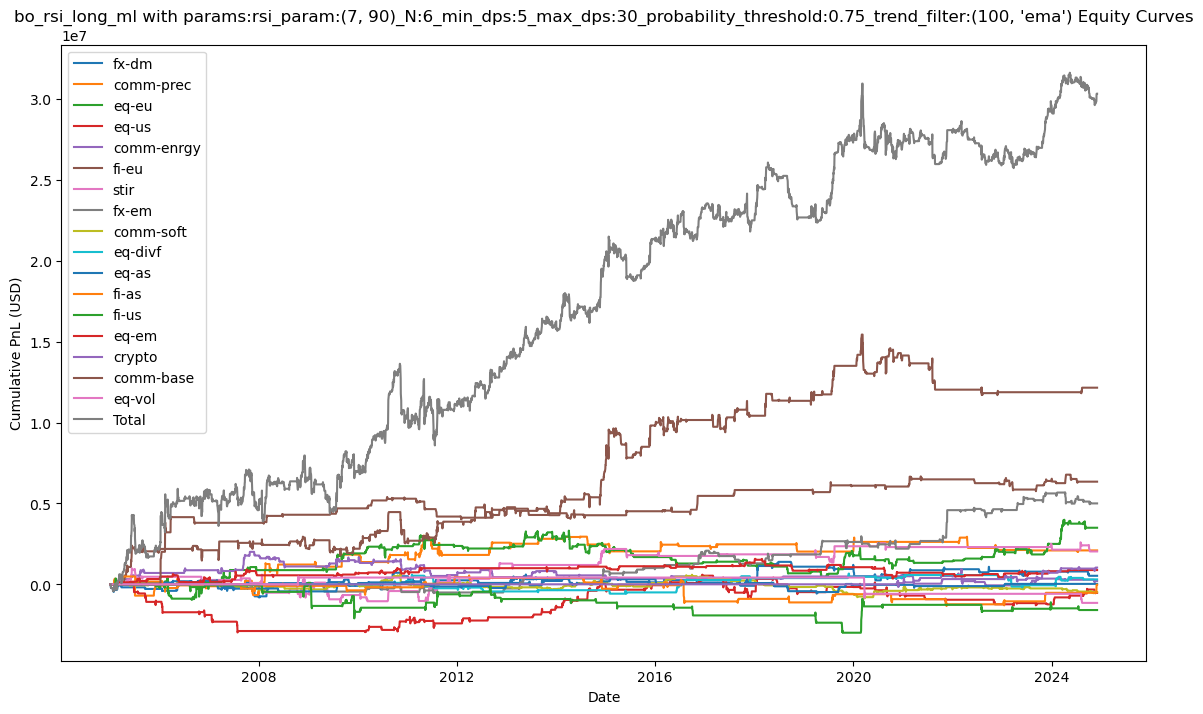

rf_long


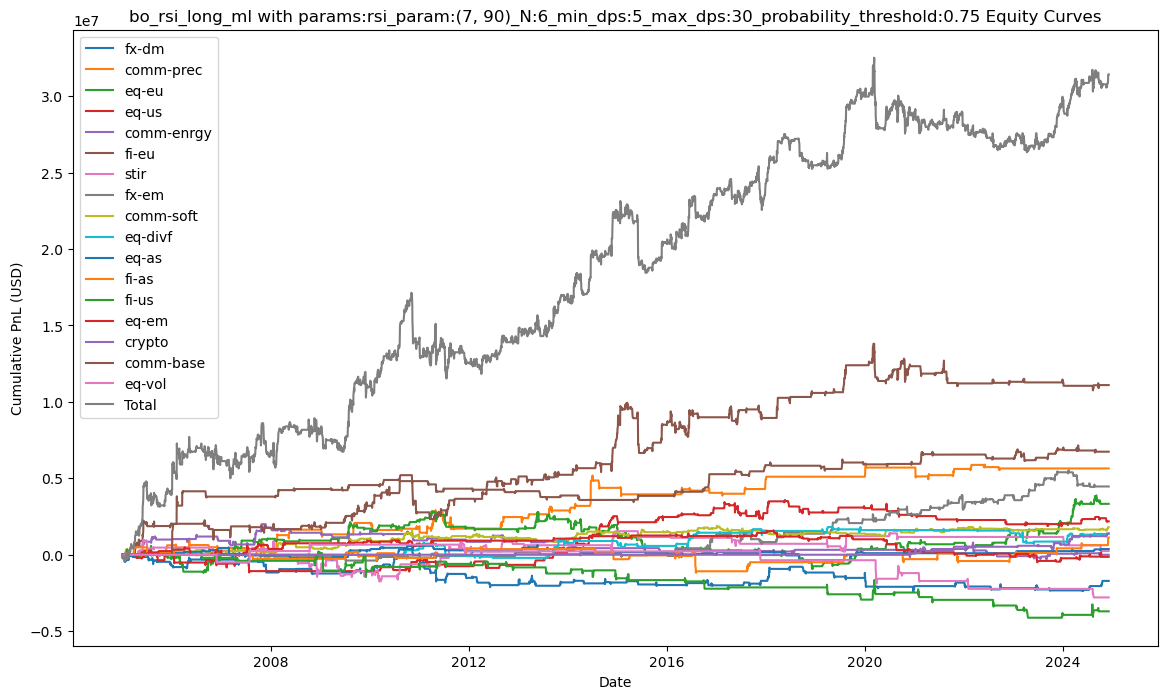

rf_long_tf_2


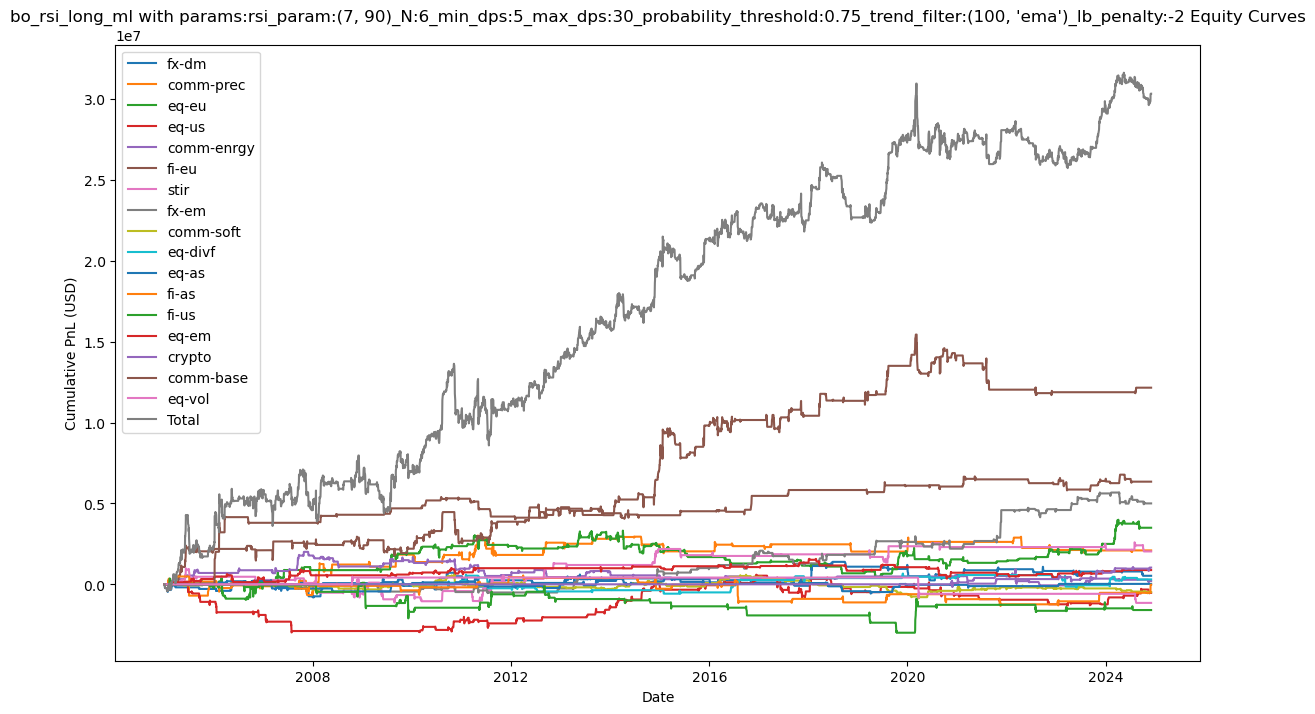

rf_long_2


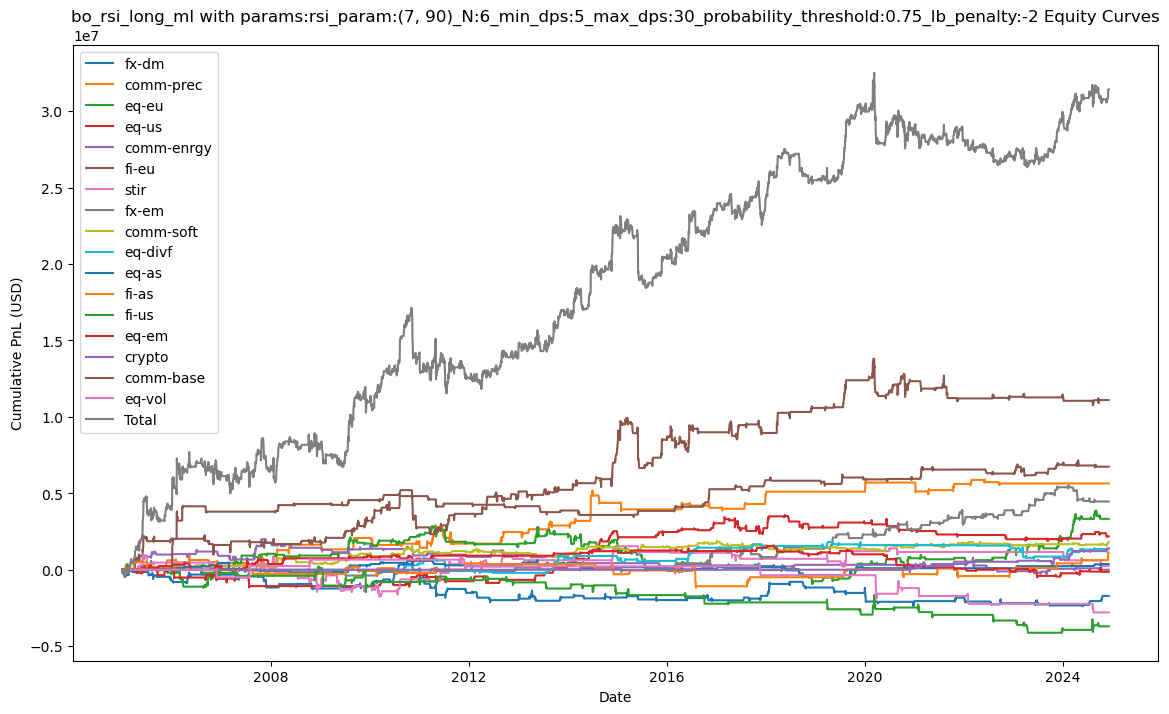

rf_short_tf


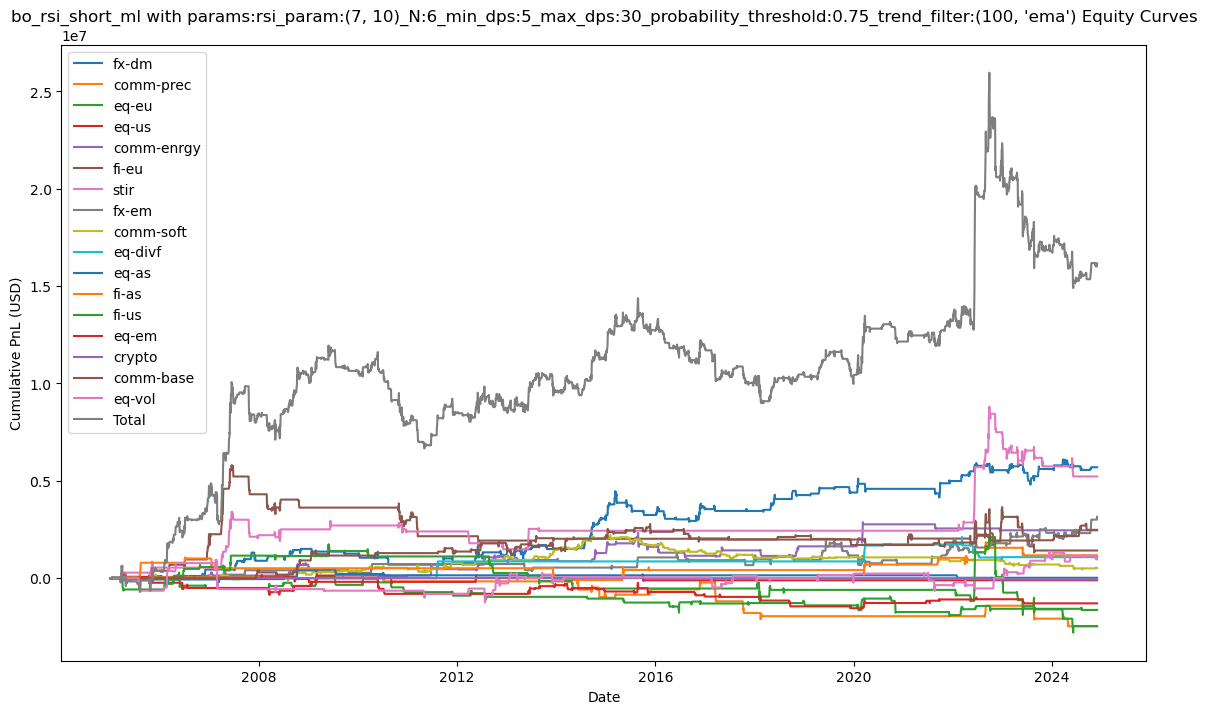

rf_short


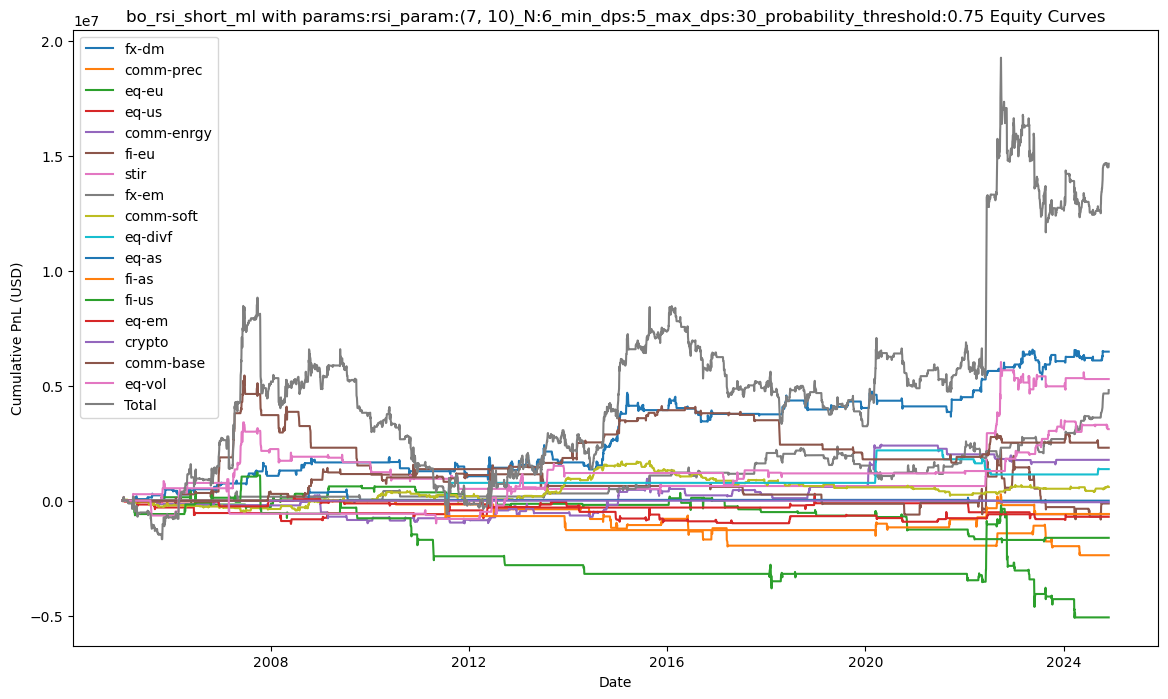

rf_short_tf_2


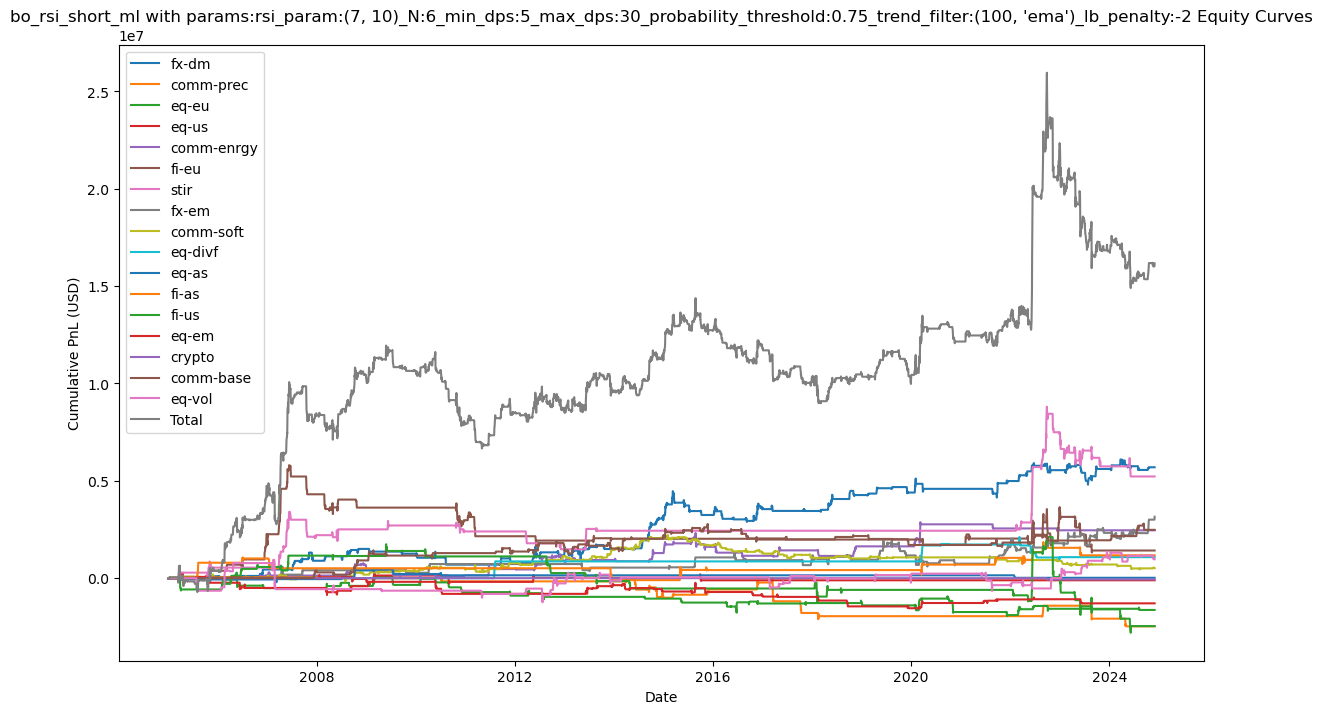

rf_short_2


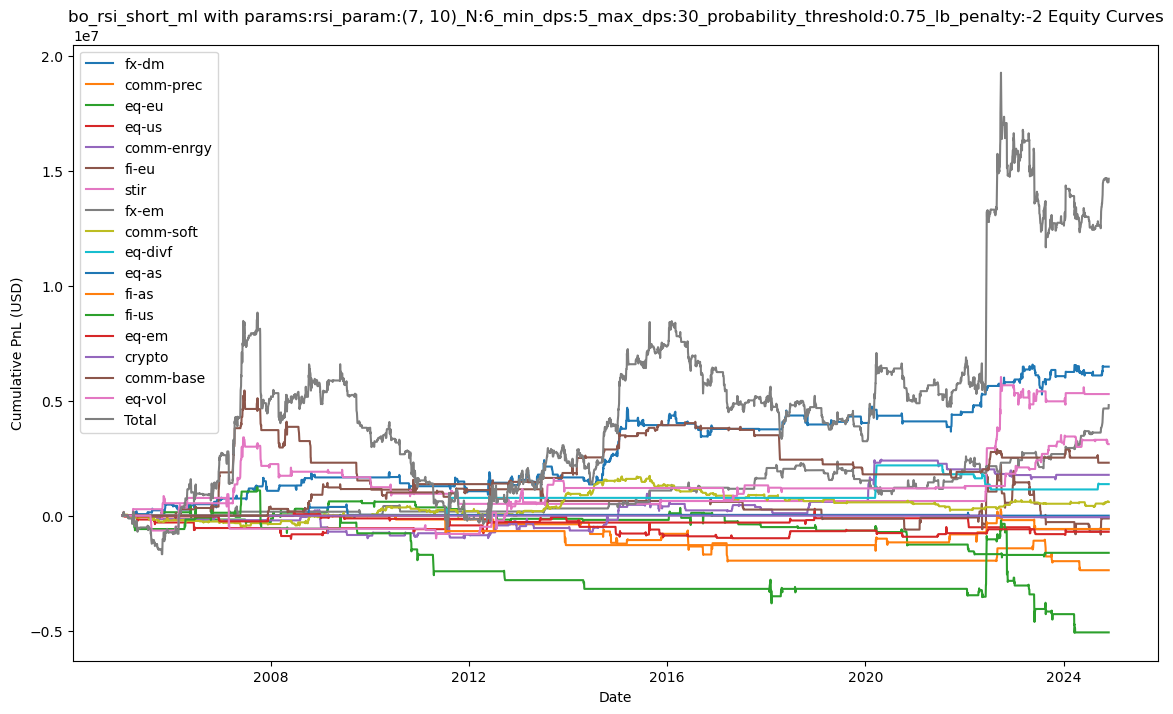

In [8]:
pnl_ts = {}
perf_dfs = {}
pnl_dfs = {}
stats_dfs = {}

start_date = '01012005'

for tr in trading_rules_dict.values():
    print(tr.name_lbl)
    tmppnldf = tr.plot_equity(byac=True,totalsys=True, start_date=start_date)
    pnl_ts[tr.name_lbl] = tmppnldf
    tmpdf = tr.perf_table(byac=True,metric='sharpe', start_date=start_date)
    perf_dfs[tr.name_lbl] = tmpdf
    tmpdf = tr.perf_table(byac=True, metric='pnl', start_date=start_date)
    pnl_dfs[tr.name_lbl] = tmpdf
    tmpdf = tr.calculate_statistics(start_date=start_date)
    stats_dfs[tr.name_lbl] = tmpdf

In [11]:
stats_dfs = {}

start_date = '01012015'

for tr in trading_rules_dict.values():
    tmpdf = tr.calculate_statistics(start_date=start_date)
    stats_dfs[tr.name_lbl] = tmpdf


# Initialize an empty list to store individual DataFrames
combined_list = []

# Iterate through the dictionary and modify each DataFrame
for key, df in stats_dfs.items():
    # Replace the row index 'Total' with the dictionary key
    df = df.rename(index={'Total': key})
    # Append the modified DataFrame to the list
    combined_list.append(df)

# Concatenate all DataFrames into one
combined_df = pd.concat(combined_list).sort_index()

combined_df

,Total PnL,Average Ann. PnL,Average Ann. Vol,Sharpe Ratio (ann.),Sortino Ratio (ann.),Max drawdown,Average drawdown,Max drawdown Duration,Avg Drawdown Duration,Total Number of Drawdowns,...,Daily Left Tail,Daily Right Tail,Weekly Left Tail,Weekly Right Tail,Monthly Left Tail,Monthly Right Tail,Quarterly Left Tail,Quarterly Right Tail,Yearly Left Tail,Yearly Right Tail
Column,,,,,,,,,,,,,,,,,,,,,
rf_long,"9,184,164","894,976","2,377,825",0.38,0.39,"6,188,545","2,736,057",1234,64.1,39,...,5.38,3.36,3.49,1.95,2.42,1.51,1.64,1.48,0.53,0.58
rf_long_2,"9,184,164","894,976","2,377,825",0.38,0.39,"6,188,545","2,736,057",1234,64.1,39,...,5.38,3.36,3.49,1.95,2.42,1.51,1.64,1.48,0.53,0.58
rf_long_tf,"10,186,815","993,067","2,303,969",0.43,0.45,"5,224,601","2,238,974",1049,67.1,37,...,5.75,6.15,3.40,2.87,1.14,1.80,0.83,1.72,0.79,0.92
rf_long_tf_2,"10,186,815","993,067","2,303,969",0.43,0.45,"5,224,601","2,238,974",1049,67.1,37,...,5.75,6.15,3.40,2.87,1.14,1.80,0.83,1.72,0.79,0.92
rf_short,"10,954,311","1,068,300","2,395,583",0.45,0.46,"7,595,718","3,303,395",1653,158.6,16,...,19.3,-24.3,4.56,9.86,1.37,6.18,1.01,7.77,0.69,97.4
rf_short_2,"10,954,311","1,068,300","2,395,583",0.45,0.46,"7,595,718","3,303,395",1653,158.6,16,...,19.3,-24.3,4.56,9.86,1.37,6.18,1.01,7.77,0.69,97.4
rf_short_tf,"4,924,512","480,254","2,445,023",0.20,0.17,"11,060,466","3,758,760",1768,169.7,15,...,50.6,-50.2,9.30,8.69,2.07,5.98,1.29,5.82,1.01,2.93
rf_short_tf_2,"4,924,512","480,254","2,445,023",0.20,0.17,"11,060,466","3,758,760",1768,169.7,15,...,50.6,-50.2,9.30,8.69,2.07,5.98,1.29,5.82,1.01,2.93
